In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
CURRENT_YEAR=2026

In [3]:
df_raw = pd.read_csv('../Dataset/car_auction_train.csv')
df_raw.shape

(447048, 12)

In [4]:
print(df_raw.dtypes)
df_raw.head()

year              int64
make                str
model               str
trim                str
body                str
transmission        str
state               str
condition       float64
odometer        float64
color               str
interior            str
sellingprice      int64
dtype: object


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2012,Kia,Soul,+,Wagon,automatic,ne,4.0,53070.0,gray,black,10100
1,2012,Honda,Civic,LX,Sedan,automatic,ga,2.6,45085.0,gray,gray,10300
2,2002,Honda,Civic,EX,Sedan,automatic,ca,2.2,136649.0,black,gray,3300
3,2002,Dodge,Grand Caravan,Sport,Minivan,automatic,oh,1.9,156991.0,silver,gray,600
4,2010,Chevrolet,Silverado 1500,LT,Crew Cab,NaN,fl,3.4,42421.0,blue,black,21100


## Missing values

In [5]:
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'count': miss, 'pct_%': miss_pct})
miss_df = miss_df[miss_df['count'] > 0].sort_values('pct_%', ascending=False)
print(miss_df)

              count  pct_%
transmission  52299  11.70
color         20361   4.55
interior      14155   3.17
body          10593   2.37
condition      9437   2.11
trim           8570   1.92
model          8372   1.87
make           8287   1.85
odometer         69   0.02


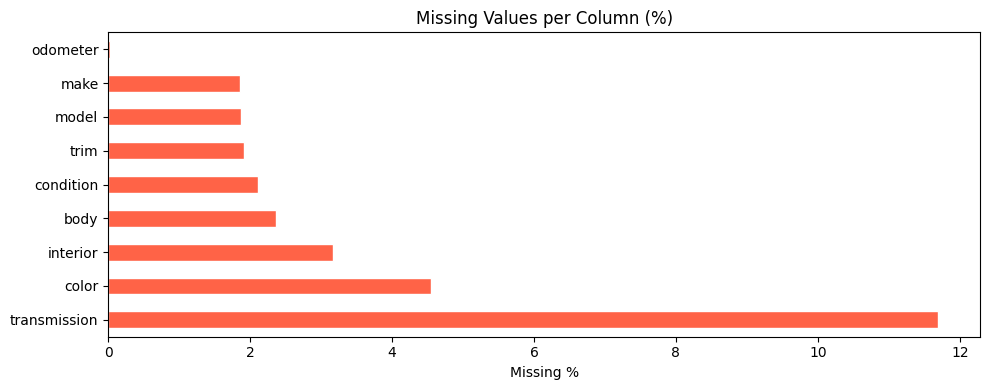

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
miss_df['pct_%'].plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Missing Values per Column (%)')
ax.set_xlabel('Missing %')
plt.tight_layout()
plt.show()

FINDINGS → DECISIONS:
transmission 11.7% missing -> fill 'automatic' (380k auto vs 14k manual; mode)
color        4.6% missing  -> fill 'Unknown'
interior     3.2% missing  -> fill 'Unknown'
body         2.4% missing  -> fill 'Unknown'
condition    2.1% missing  -> fill median (numeric, looks random)
make/model/trim <2% missing -> fill 'Unknown'
odometer     0.01% missing -> fill median

## Outliers

In [7]:
prices = df_raw['sellingprice']
print(prices.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

count    447048.000000
mean      13609.877854
std        9756.832996
min           1.000000
1%          500.000000
5%         1500.000000
25%        6900.000000
50%       12100.000000
75%       18200.000000
95%       30700.000000
99%       45000.000000
max      230000.000000
Name: sellingprice, dtype: float64


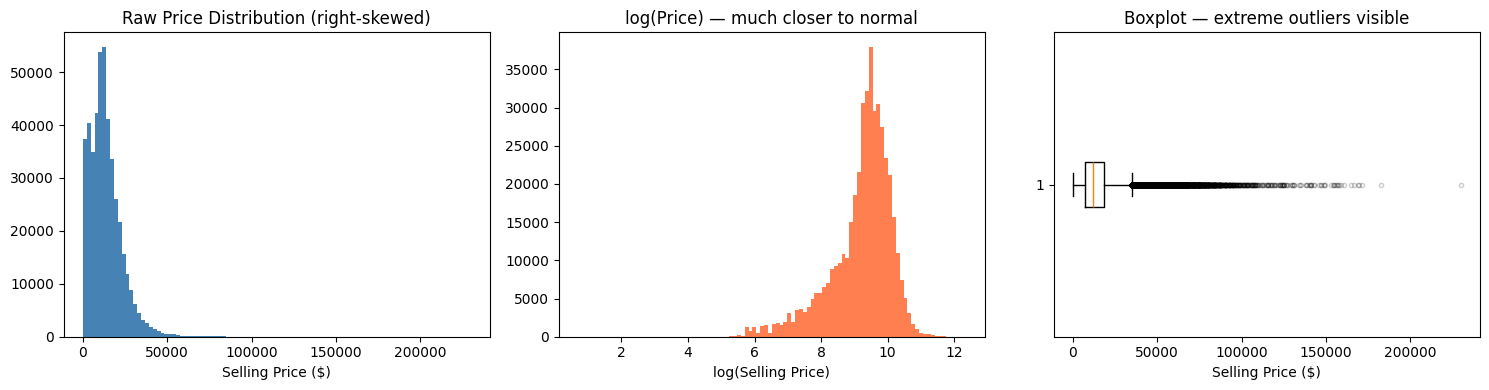

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(prices, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Price Distribution (right-skewed)')
axes[0].set_xlabel('Selling Price ($)')

axes[1].hist(np.log1p(prices), bins=100, color='coral', edgecolor='none')
axes[1].set_title('log(Price) — much closer to normal')
axes[1].set_xlabel('log(Selling Price)')

axes[2].boxplot(prices, vert=False, flierprops=dict(marker='.', alpha=0.2))
axes[2].set_title('Boxplot — extreme outliers visible')
axes[2].set_xlabel('Selling Price ($)')
plt.tight_layout()
plt.show()


In [9]:
Q1, Q3 = prices.quantile(0.25), prices.quantile(0.75)
IQR = Q3 - Q1
print(f"\n3×IQR fences -> lower: ${Q1 - 3*IQR}   upper: ${Q3 + 3*IQR}")
print(f"Rows below $500:   {(prices < 500).sum()}  (salvage/data errors)")
print(f"Rows above $100k:  {(prices > 100_000).sum()}  (exotic outliers)")


3×IQR fences -> lower: $-27000.0   upper: $52100.0
Rows below $500:   4321  (salvage/data errors)
Rows above $100k:  127  (exotic outliers)


DECISION: Drop prices < $500 (salvage titles, data errors) AND
cap at 3×IQR upper fence. 1.5×IQR is too aggressive — removes
legitimate high-value trucks and luxury cars.

In [10]:
odo = df_raw['odometer'].dropna()
print(odo.describe(percentiles=[.95,.99,.999]))

count    446979.000000
mean      68353.615745
std       53455.257534
min           1.000000
95%      170027.300000
99%      226461.080000
99.9%    312470.684000
max      999999.000000
Name: odometer, dtype: float64


In [11]:
print(f"Rows > 300k miles: {(odo > 300_000).sum()}")
print(f"Rows > 500k miles: {(odo > 500_000).sum()}")

Rows > 300k miles: 603
Rows > 500k miles: 67


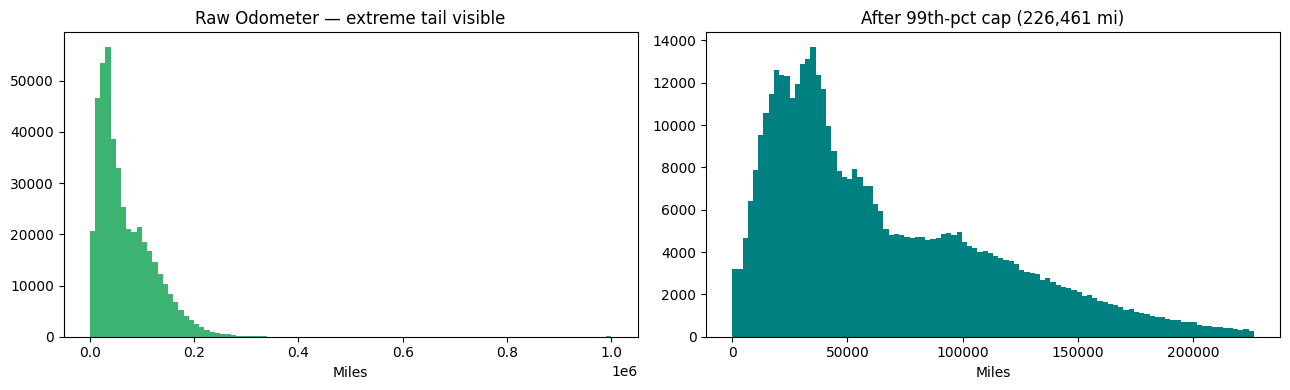

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(odo, bins=100, color='mediumseagreen', edgecolor='none')
axes[0].set_title('Raw Odometer — extreme tail visible')
axes[0].set_xlabel('Miles')

p99 = odo.quantile(0.99)
axes[1].hist(odo[odo <= p99], bins=100, color='teal', edgecolor='none')
axes[1].set_title(f'After 99th-pct cap ({p99:,.0f} mi)')
axes[1].set_xlabel('Miles')
plt.tight_layout()
plt.show()

DECISION: Cap at 99th percentile (226k miles). Values like 999,999
are data entry errors. Capping preserves other features of the row.s

In [13]:
df_raw["year"].describe()

count    447048.000000
mean       2010.035294
std           3.967981
min        1982.000000
25%        2007.000000
50%        2012.000000
75%        2013.000000
max        2015.000000
Name: year, dtype: float64

In [14]:
print("Pre-1990 rows:", (df_raw['year'] < 1990).sum())

Pre-1990 rows: 50


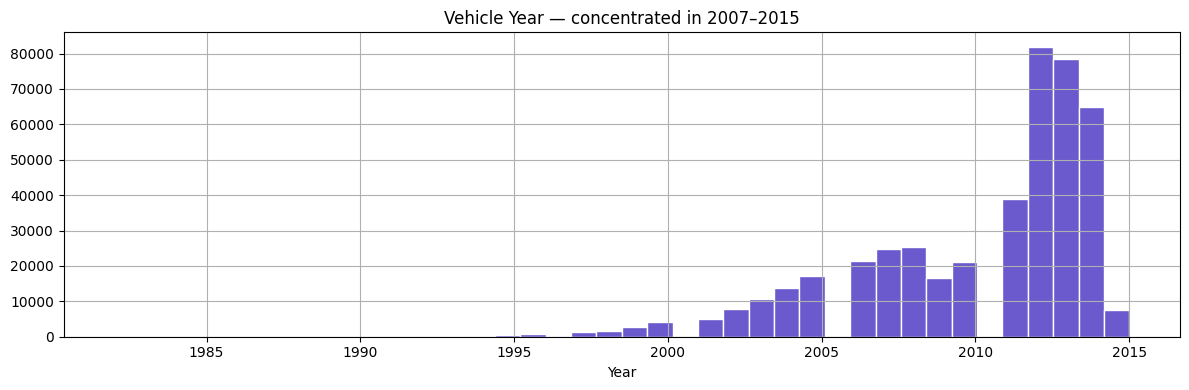

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
df_raw['year'].hist(bins=40, ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Vehicle Year — concentrated in 2007–2015')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

DECISION: Keep all years. Max=2015, Min=1982, both plausible.
car_age feature will capture the effect of year more usefully

# Condition

In [16]:
cond = df_raw['condition'].dropna()
print(cond.describe())

count    437611.000000
mean          3.424681
std           0.950395
min           1.000000
25%           2.700000
50%           3.600000
75%           4.200000
max           5.000000
Name: condition, dtype: float64


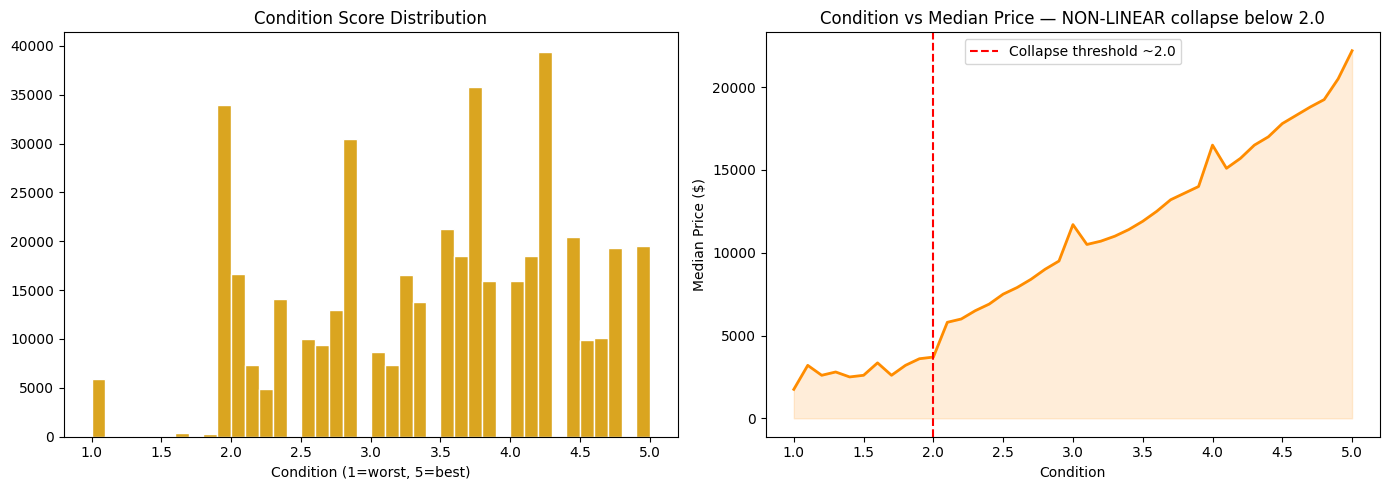

In [17]:
tmp = df_raw.copy()
tmp['condition']    = tmp['condition']
tmp['sellingprice'] = tmp['sellingprice']
cp = tmp.groupby('condition')['sellingprice'].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cond, bins=40, color='goldenrod', edgecolor='white')
axes[0].set_title('Condition Score Distribution')
axes[0].set_xlabel('Condition (1=worst, 5=best)')

axes[1].plot(cp['condition'], cp['sellingprice'], color='darkorange', linewidth=2)
axes[1].fill_between(cp['condition'], cp['sellingprice'], alpha=0.15, color='darkorange')
axes[1].axvline(x=2.0, color='red', linestyle='--', label='Collapse threshold ~2.0')
axes[1].set_title('Condition vs Median Price — NON-LINEAR collapse below 2.0')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Median Price ($)')
axes[1].legend()
plt.tight_layout()
plt.show()

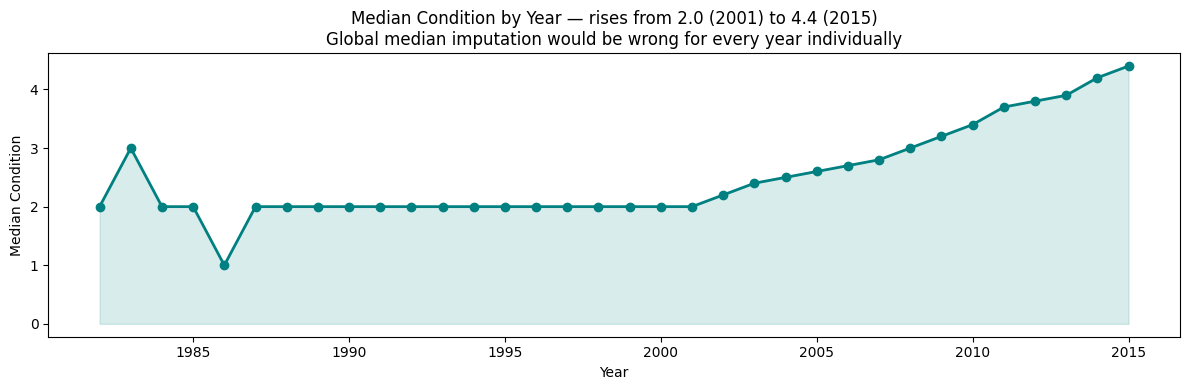

In [18]:
yr_cond = tmp.groupby('year')['condition'].median().reset_index()
plt.figure(figsize=(12, 4))
plt.plot(yr_cond['year'], yr_cond['condition'], marker='o', color='teal', linewidth=2)
plt.fill_between(yr_cond['year'], yr_cond['condition'], alpha=0.15, color='teal')
plt.title('Median Condition by Year — rises from 2.0 (2001) to 4.4 (2015)\n'
          'Global median imputation would be wrong for every year individually')
plt.xlabel('Year')
plt.ylabel('Median Condition')
plt.tight_layout()
plt.show()

KEY FINDING 1: Price collapses sharply below condition 2.0 (non-linear).

KEY FINDING 2: Median condition rises steadily from 2.0 (year 2001) → 4.4 (year 2015).

All 9,437 missing-condition rows have a valid year.

DECISION: Impute missing condition with PER-YEAR median, not global median.
Global median (3.6) would badly over-estimate condition for 2001–2006 cars
and under-estimate for 2013–2015 cars.

# categorical columns

In [19]:
cat_cols = ['make','model','trim','body','transmission','state','color','interior']
for col in cat_cols:
    print(f"  {col:15s}: {df_raw[col].nunique():>5} unique")

  make           :    93 unique
  model          :   954 unique
  trim           :  1902 unique
  body           :    84 unique
  transmission   :     2 unique
  state          :    38 unique
  color          :    19 unique
  interior       :    16 unique


In [20]:
print("\nTransmission value counts:")
print(df_raw['transmission'].value_counts())

print("\nBody value counts:")
print(df_raw['body'].value_counts().head(8))


Transmission value counts:
transmission
automatic    380708
manual        14041
Name: count, dtype: int64

Body value counts:
body
Sedan        159574
SUV           95363
sedan         33574
suv           19587
Minivan       17080
Hatchback     17023
Coupe         11766
Wagon         10941
Name: count, dtype: int64


DECISIONS:
body -> title-case normalisation (merges 'Sedan'/'sedan' duplicates)

transmission -> fill missing with 'automatic' (96% of known values)

model/trim -> group < 0.1% frequency into 'Other' (1902 trim levels!)

make -> 93 unique — all reasonable, keep as-is

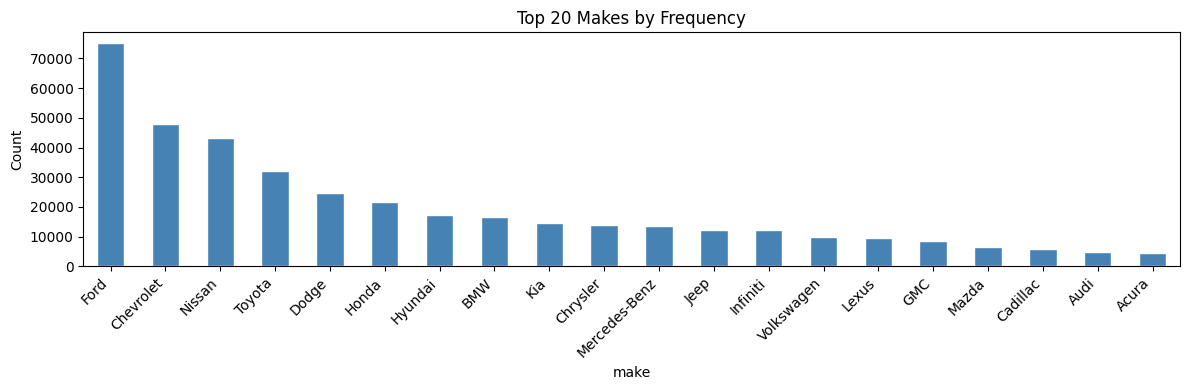

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
df_raw['make'].value_counts().head(20).plot(kind='bar', ax=ax,
                                             color='steelblue', edgecolor='white')
ax.set_title('Top 20 Makes by Frequency')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Drop rows with missing target — the only operation allowed before split
df_clean = df_raw.dropna(subset=['sellingprice']).copy()

In [23]:
# Remove egregious price outliers (below $500 — salvage/data errors)
# Upper cap will be computed from train only below
df_clean = df_clean[df_clean['sellingprice'] >= 1000]

splitting data before any operation(to prevent data leakage)

In [24]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42)
train_df = train_df.copy()
val_df   = val_df.copy()

print(f"Train rows: {len(train_df):,}")
print(f"Val rows:   {len(val_df):,}")

Train rows: 347,439
Val rows:   86,860


In [25]:
Q1_tr = train_df['sellingprice'].quantile(0.25)
Q3_tr = train_df['sellingprice'].quantile(0.75)
IQR_tr = Q3_tr - Q1_tr
price_upper = Q3_tr + 3 * IQR_tr

In [26]:
before_tr = len(train_df)
train_df = train_df[train_df['sellingprice'] <= price_upper]
print(f"[Train] Price cap at ${price_upper:,.0f}: removed {before_tr - len(train_df):,} rows")

[Train] Price cap at $51,500: removed 1,971 rows


In [27]:
# Apply same cap to val (do NOT recompute from val)
before_val = len(val_df)
val_df = val_df[val_df['sellingprice'] <= price_upper]
print(f"[Val]   Price cap applied: removed {before_val - len(val_df):,} rows")

[Val]   Price cap applied: removed 501 rows


In [28]:
odo_cap = train_df['odometer'].quantile(0.99)
odo_median_train = train_df['odometer'].median()

train_df['odometer'] = train_df['odometer'].clip(upper=odo_cap).fillna(odo_median_train)

# Apply same cap to val
val_df['odometer']   = val_df['odometer'].clip(upper=odo_cap).fillna(odo_median_train)
print(f"\n[Train] Odometer cap: {odo_cap:,.0f} mi  |  median fill: {odo_median_train:,.0f}")


[Train] Odometer cap: 213,380 mi  |  median fill: 50,875


In [29]:
# Condition — per-year median imputation, fit on train 
year_cond_map = train_df.groupby('year')['condition'].median().to_dict()
global_cond   = train_df['condition'].median()

In [30]:
def impute_condition(df, year_map, global_fallback):
    def _fill(row):
        if pd.notna(row['condition']):
            return row['condition']
        val = year_map.get(row['year'], global_fallback)
        if pd.isna(val):
            return global_fallback
        return val
    df['condition'] = df.apply(_fill, axis=1)
    return df

In [31]:
train_df = impute_condition(train_df, year_cond_map, global_cond)
val_df   = impute_condition(val_df,   year_cond_map, global_cond)

# Val uses the map built from train — no val data leaks back
print(f"\n[Train] Condition per-year map computed on train only")
print(f"Sample: {dict(list(year_cond_map.items())[-4:])}")


[Train] Condition per-year map computed on train only
Sample: {2012: 3.8, 2013: 3.9, 2014: 4.2, 2015: 4.4}


In [32]:
def clean_cats(df):
    df['transmission'] = df['transmission'].fillna('automatic')
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip().str.title()
    return df

train_df = clean_cats(train_df)
val_df   = clean_cats(val_df)

In [33]:
# Rare category grouping — threshold from train only
rare_map = {}   # col → set of rare values (from train)
for col in ['model', 'trim']:
    freq = train_df[col].value_counts(normalize=True)
    rare = set(freq[freq < 0.001].index)
    rare_map[col] = rare

    train_df[col] = train_df[col].where(~train_df[col].isin(rare), 'Other')
    val_df[col]   = val_df[col].where(~val_df[col].isin(rare), 'Other')

    # Val: any category not seen in train's top set → 'Other'
    print(f"[Train] {col}: {len(rare)} rare values → 'Other'")

[Train] model: 576 rare values → 'Other'
[Train] trim: 1528 rare values → 'Other'


In [34]:
def engineer(df):
    df['car_age']             = (CURRENT_YEAR - df['year']).clip(lower=1)
    df['usage_intensity']     = df['odometer'] / df['car_age']
    df['condition_age_ratio'] = df['condition'] / df['car_age']
    df['log_odometer']        = np.log1p(df['odometer'])
    return df

train_df = engineer(train_df)
val_df   = engineer(val_df)

# Encoding

In [35]:
# Target Encoding — K-Fold OOF on train, full-train means on val

#   We didnt use LabelEncoder as it assigns arbitrary integers 
#   Ford=23, Toyota=67) — no ordinal meaning.
#   Model wastes capacity learning these numbers are meaningless.
#   Target Encoding: Replaces each category with the mean sellingprice of 
#   that category.mImmediately meaningful signal, especially for high-cardinality

# WHY K-Fold OOF (Out-of-Fold) on train:
#   Naive target encoding on train = leakage. Each row's own price
#   contributes to its own encoding → model sees the answer.
#   Fix: encode each train row using means from the OTHER folds only.
#   Val rows are encoded using full train means (no val data used).

# SMOOTHING formula:
#   smoothed_mean = (count × cat_mean + k × global_mean) / (count + k)
#   where k=10. Rare categories (few rows) shrink toward global mean.
#   Prevents a category with 2 cars from getting a wildly unstable encoding.
 
from sklearn.model_selection import KFold
def target_encode(train, val, cat_cols, target, n_splits=5, smoothing=10):
    """
    K-fold OOF target encoding.
    Returns encoded train, encoded val, and the full-train means dict
    (saved to pkl for use in the agent at inference time).
    """
    global_mean   = train[target].mean()
    train_encoded = train.copy()
    val_encoded   = val.copy()
    full_means    = {}   # col -> {category: smoothed_mean}  used for val + agent
 
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
 
    for col in cat_cols:
        # Full-train smoothed means (for val and agent inference) 
        stats = train.groupby(col)[target].agg(['mean', 'count'])
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + smoothing * global_mean)
            / (stats['count'] + smoothing)
        )
        full_means[col] = stats['smoothed'].to_dict()
 
        # OOF encoding for train rows
        train_encoded[col + '_te'] = global_mean   # default, overwritten below
 
        for fold_tr_idx, fold_val_idx in kf.split(train):
            fold_tr   = train.iloc[fold_tr_idx]
            fold_stats = fold_tr.groupby(col)[target].agg(['mean', 'count'])
            fold_stats['smoothed'] = (
                (fold_stats['count'] * fold_stats['mean'] + smoothing * global_mean)
                / (fold_stats['count'] + smoothing)
            )
            fold_map = fold_stats['smoothed'].to_dict()
 
            # Map OOF rows using this fold's means; unseen → global_mean
            train_encoded.loc[
                train.index[fold_val_idx], col + '_te'
            ] = (
                train[col].iloc[fold_val_idx]
                    .map(fold_map)
                    .fillna(global_mean)
                    .values
            )
 
        # Val encoding using full-train means (no val data used)
        val_encoded[col + '_te' ] = (
            val[col].map(full_means[col]).fillna(global_mean)
        )
 
    return train_encoded, val_encoded, full_means, global_mean
 
print("\n[Encoding] Running 5-fold OOF target encoding on train...")
train_df, val_df, te_means, te_global_mean = target_encode(
    train_df, val_df, cat_cols, 'sellingprice', n_splits=5, smoothing=10
)
print("[Encoding] Done. Val encoded using full-train means only.")


[Encoding] Running 5-fold OOF target encoding on train...
[Encoding] Done. Val encoded using full-train means only.


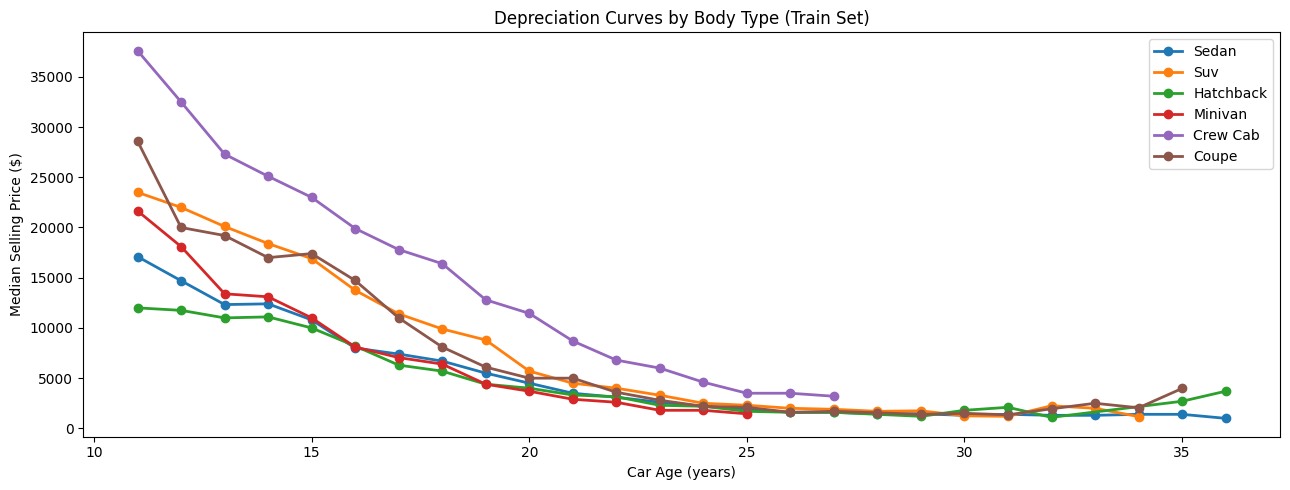

In [36]:
#Depreciation Curve
top_bodies = train_df['body'].value_counts().head(6).index
dep = (train_df[train_df['body'].isin(top_bodies)]
       .groupby(['body', 'car_age'])['sellingprice']
       .median().reset_index())

plt.figure(figsize=(13, 5))
for body in top_bodies:
    s = dep[dep['body'] == body]
    plt.plot(s['car_age'], s['sellingprice'], marker='o', linewidth=2, label=body)
plt.title('Depreciation Curves by Body Type (Train Set)')
plt.xlabel('Car Age (years)')
plt.ylabel('Median Selling Price ($)')
plt.legend(); 
plt.tight_layout()
plt.show()

# FINDING: Crew Cabs command highest prices (~$38k) and depreciate slowest.
# SUVs start high but converge with Sedans by age 18–20.
# Coupes outlast SUVs in value retention after age 18.

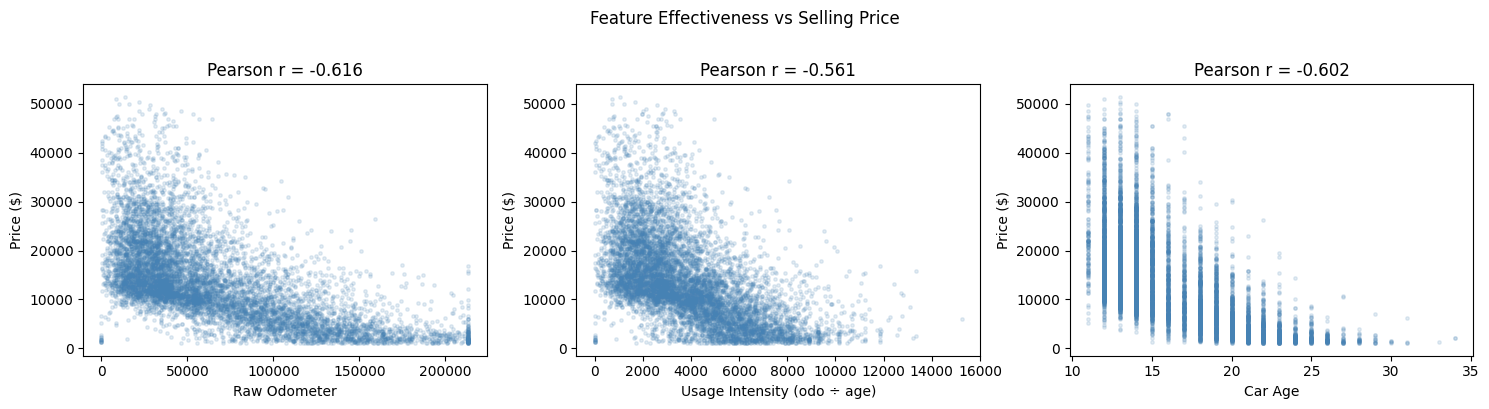

In [37]:
# Usage Intensity vs Raw Odometer 
from scipy.stats import pearsonr
sample = train_df.sample(min(8000, len(train_df)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
        ['odometer', 'usage_intensity', 'car_age'],
        ['Raw Odometer', 'Usage Intensity (odo ÷ age)', 'Car Age']):
    r, _ = pearsonr(sample[col], sample['sellingprice'])
    ax.scatter(sample[col], sample['sellingprice'], alpha=0.15, s=6, color='steelblue')
    ax.set_xlabel(label); ax.set_ylabel('Price ($)')
    ax.set_title(f'Pearson r = {r:.3f}')
plt.suptitle('Feature Effectiveness vs Selling Price', y=1.01)
plt.tight_layout()
plt.show()



Premium over body-type average ($):
 transmission         Automatic  Manual
body                                  
Access Cab                 NaN     NaN
Beetle Convertible         NaN     NaN
Cab Plus                   NaN     NaN
Cab Plus 4                 NaN     NaN
Club Cab                   NaN     NaN
Convertible                NaN     NaN
Coupe                      NaN     NaN
Crew Cab                   0.0 -8900.0
Crewmax Cab                NaN     NaN
Cts Coupe                  NaN     NaN
Cts Wagon                  NaN     NaN
Cts-V Coupe                NaN     NaN
Double Cab                 NaN     NaN
E-Series Van               NaN     NaN
Elantra Coupe              NaN     NaN
Extended Cab               NaN     NaN
G Convertible              NaN     NaN
G Coupe                    NaN     NaN
G Sedan                    NaN     NaN
G37 Convertible            NaN     NaN
G37 Coupe                  NaN     NaN
Genesis Coupe              NaN     NaN
Hatchback                1

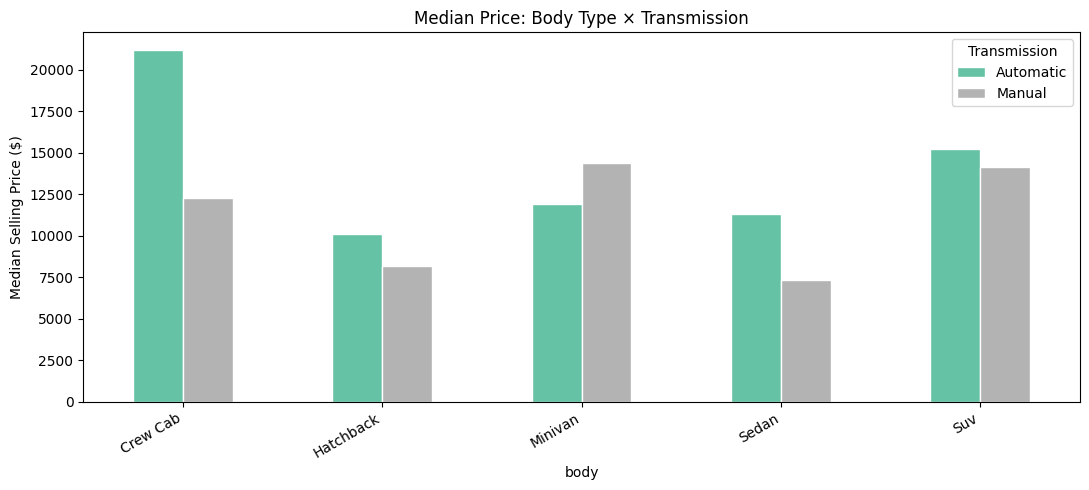

In [38]:
# Transmission × Body Type 
top5 = train_df['body'].value_counts().head(5).index
seg  = train_df[train_df['body'].isin(top5)]
pivot = seg.groupby(['body', 'transmission'])['sellingprice'].median().unstack()
premium = pivot.subtract(
    train_df.groupby('body')['sellingprice'].median(), axis=0).round(0)
print("\nPremium over body-type average ($):\n", premium)

pivot.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white')
plt.title('Median Price: Body Type × Transmission')
plt.ylabel('Median Selling Price ($)')
plt.xticks(rotation=30, ha='right'); plt.legend(title='Transmission')
plt.tight_layout()
plt.show()


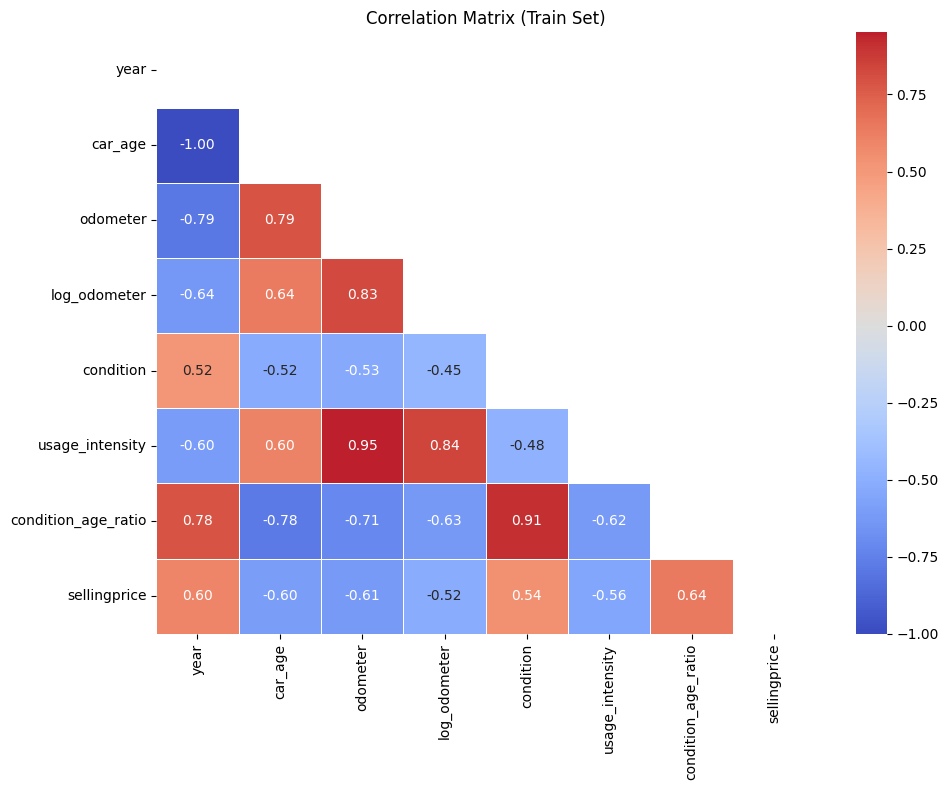

In [39]:
# Correlation Heatmap 
num_cols = ['year', 'car_age', 'odometer', 'log_odometer', 'condition',
            'usage_intensity', 'condition_age_ratio', 'sellingprice']
corr = train_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (Train Set)')
plt.tight_layout()
plt.show()


C:\Users\swaya\AppData\Local\Temp\ipykernel_20724\1907517401.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df[train_df['make'].isin(top8)],


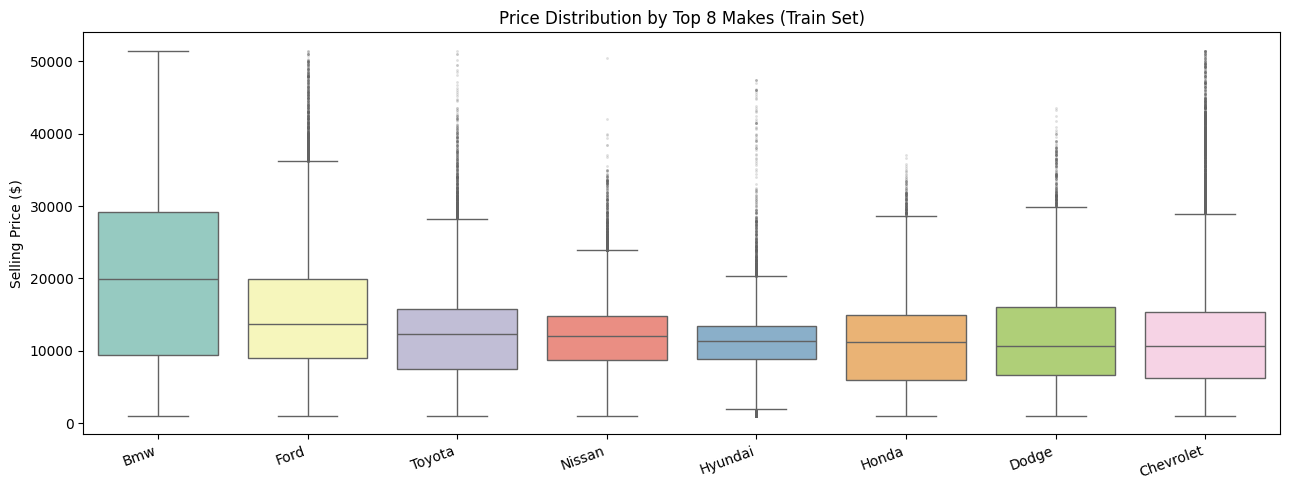

In [40]:
# Top Makes Price Distribution 
top8 = train_df['make'].value_counts().head(8).index
make_order = (train_df[train_df['make'].isin(top8)]
              .groupby('make')['sellingprice']
              .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=train_df[train_df['make'].isin(top8)],
            x='make', y='sellingprice', order=make_order,
            ax=ax, palette='Set3',
            flierprops=dict(marker='.', alpha=0.2, markersize=2))
ax.set_title('Price Distribution by Top 8 Makes (Train Set)')
ax.set_xlabel(''); ax.set_ylabel('Selling Price ($)')
plt.xticks(rotation=20, ha='right'); 
plt.tight_layout()
plt.show()


In [41]:
FEATURE_COLS = [
    'car_age', 'log_odometer', 'condition',
    'usage_intensity', 'condition_age_ratio',
    'make_te', 'model_te', 'trim_te', 'body_te',
    'transmission_te', 'state_te', 'color_te', 'interior_te'
]
X_train = train_df[FEATURE_COLS]
y_train = train_df['sellingprice']

X_val   = val_df[FEATURE_COLS]
y_val   = val_df['sellingprice']

# Final check — no NaNs
assert X_train.isnull().sum().sum() == 0, "NaNs in X_train!"
assert X_val.isnull().sum().sum() == 0,   "NaNs in X_val!"
print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")


X_train: (345468, 13)  |  X_val: (86359, 13)


In [42]:
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

baseline = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

baseline.fit(X_train, y_train)
base_preds = baseline.predict(X_val)
base_rmse = np.sqrt(mean_squared_error(y_val, base_preds))
print(f"[Model] Baseline RMSE: ${base_rmse:,.2f}")


[Model] Baseline RMSE: $2,396.26


In [49]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

param_dist = { # Boosting rounds 
    'n_estimators': randint(300, 2500), 

    # Tree structure 
    'max_depth': randint(3, 12), 

    # Learning rate 
    'learning_rate': loguniform(0.005, 0.15), 

    # Sampling 
    'subsample': uniform(0.6, 0.4), 
    'colsample_bytree': uniform(0.5, 0.5), 

    # Regularization 
    'reg_alpha': loguniform(1e-4, 10), 
    'reg_lambda': loguniform(1e-3, 30)
}

search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=2,
    verbose=2,
    random_state=42
)

In [50]:
search.fit(X_train, y_train)

best_model  = search.best_estimator_
tuned_preds = best_model.predict(X_val)
tuned_rmse  = np.sqrt(mean_squared_error(y_val, tuned_preds))

Fitting 2 folds for each of 15 candidates, totalling 30 fits
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.12684995383408856, max_depth=10, n_estimators=1938, reg_alpha=0.01694976823788473, reg_lambda=0.002802849769496466, subsample=0.7836995567863468; total time= 1.1min
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.12684995383408856, max_depth=10, n_estimators=1938, reg_alpha=0.01694976823788473, reg_lambda=0.002802849769496466, subsample=0.7836995567863468; total time=  55.3s
[CV] END colsample_bytree=0.6668543055695109, learning_rate=0.008128335438431347, max_depth=5, n_estimators=1985, reg_alpha=0.0001914511128571073, reg_lambda=1.7079535259411476, subsample=0.9754210836063001; total time=  11.7s
[CV] END colsample_bytree=0.6668543055695109, learning_rate=0.008128335438431347, max_depth=5, n_estimators=1985, reg_alpha=0.0001914511128571073, reg_lambda=1.7079535259411476, subsample=0.9754210836063001; total time=  11.4s
[CV] END colsample_bytree=0.500

In [51]:
print(f"  Baseline RMSE : ${base_rmse:,.2f}")
print(f"  Tuned RMSE    : ${tuned_rmse:,.2f}")
print(f"  Improvement   : ${base_rmse - tuned_rmse:,.2f}")
print(f"  Best params   : {search.best_params_}")

  Baseline RMSE : $2,396.26
  Tuned RMSE    : $2,094.36
  Improvement   : $301.90
  Best params   : {'colsample_bytree': np.float64(0.6356745158869479), 'learning_rate': np.float64(0.0837752617992515), 'max_depth': 11, 'n_estimators': 1063, 'reg_alpha': np.float64(0.10843543809852559), 'reg_lambda': np.float64(0.017206074702554055), 'subsample': np.float64(0.718509402281633)}


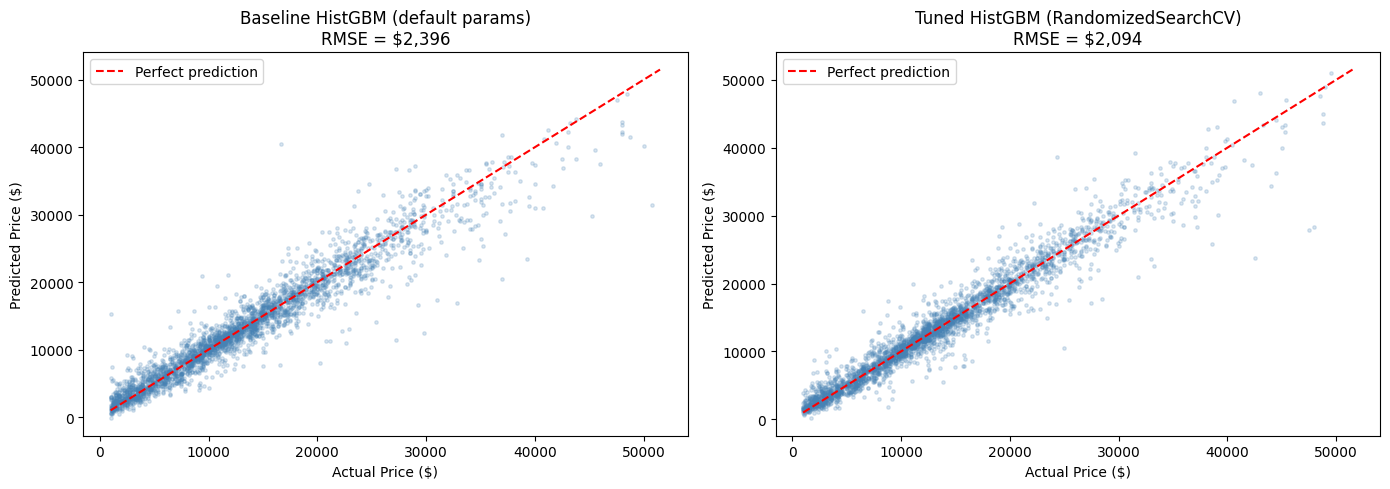

In [52]:
# Actual vs Predicted Plot (Baseline vs Tuned) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title, rmse in zip(
        axes,
        [base_preds,  tuned_preds],
        ['Baseline HistGBM (default params)',
         'Tuned HistGBM (RandomizedSearchCV)'],
        [base_rmse,   tuned_rmse]):
    idx = np.random.choice(len(y_val), 3000, replace=False)
    ax.scatter(np.array(y_val)[idx], preds[idx],
               alpha=0.2, s=6, color='steelblue')
    lims = [y_val.min(), y_val.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{title}\nRMSE = ${rmse:,.0f}')
    ax.set_xlabel('Actual Price ($)'); ax.set_ylabel('Predicted Price ($)')
    ax.legend()
plt.tight_layout()
plt.show()

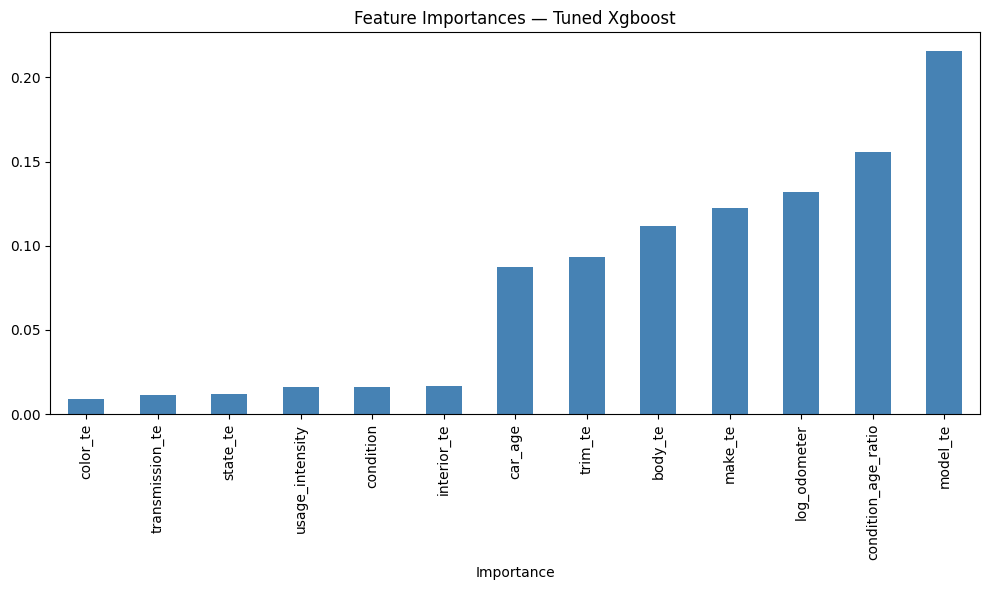


Feature importances:
            feature  importance
           model_te    0.215879
condition_age_ratio    0.155762
       log_odometer    0.131924
            make_te    0.122371
            body_te    0.111462
            trim_te    0.093599
            car_age    0.087592
        interior_te    0.017019
          condition    0.016309
    usage_intensity    0.016168
           state_te    0.011715
    transmission_te    0.011159
           color_te    0.009039


In [53]:
feat_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

feat_df.plot(kind='bar', x='feature', y='importance',
             figsize=(10, 6), color='steelblue', legend=False)
plt.title('Feature Importances — Tuned Xgboost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nFeature importances:")
print(feat_df.sort_values('importance', ascending=False).to_string(index=False))

In [54]:
model_payload = {
    'model':               best_model,
    'feature_cols':        FEATURE_COLS,
    'odo_cap':             odo_cap,
    'odo_median_train':    odo_median_train,
    'year_cond_map':       year_cond_map,     # per-year condition medians (train)
    'global_cond':         global_cond,       # fallback for unseen years
    'price_upper':         price_upper,
    'rare_map':            rare_map,          # rare model/trim values to map → 'Other'
}
import pickle
with open('model_SwayamUpadhyaya.pkl', 'wb') as f:
    pickle.dump(model_payload, f)

with open('encoders_SwayamUpadhyaya.pkl', 'wb') as f:
    pickle.dump(te_means, f)